# 🤖 Machine Learning — Aula 2: Pré-processamento de Dados
**Pós-Graduação em Ciência de Dados e Estatística — PUC Minas**

---

## 📋 Pauta da Aula

1. **Dataset** — contexto de churn bancário
2. **Análise Exploratória com `ydata-profiling`** — visão geral automatizada
3. **EDA Manual** — distribuições, correlações, outliers
4. **Pré-processamento Passo a Passo**
   - Valores Missing
   - Tratamento de Outliers
   - Encoding de Variáveis Categóricas
   - Escalonamento de Features
   - Engenharia de Atributos
5. **Seleção de Variáveis com Boruta**

> 💡 **Conceito Chave:** *"Dados são o novo petróleo, mas o Feature Engineering é a refinaria."*

---
## 📦 ETAPA 0 — Instalação de Dependências

In [ ]:
# Instalação dos pacotes necessários
!pip install -q ydata-profiling boruta scikit-learn pandas numpy matplotlib seaborn scipy

print("✅ Instalação concluída!")

In [1]:
# =============================================================
# Importações gerais
# =============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Sklearn — pré-processamento
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Boruta
from boruta import BorutaPy

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 50)
np.random.seed(42)

print("✅ Pacotes carregados com sucesso!")

✅ Pacotes carregados com sucesso!


---
## 🏗️ ETAPA 1 — Importacao do Dataset

### Contexto: Previsão de *Churn* em um Banco

Um banco deseja prever quais clientes têm maior probabilidade de cancelar seus serviços (churn). O dataset contém características demográficas, comportamentais e financeiras dos clientes.

**Variável-alvo:** `churn` (1 = cancelou, 0 = permaneceu)

In [3]:
df_raw = pd.read_csv('dados_cancelamento.csv')
df_raw.head()

,id_cliente,idade,genero,pais,nivel_educacao,score_credito,tipo_conta,saldo_conta,saldo_normalizado,salario_anual,num_produtos,num_transacoes,tempo_cliente,cartao_credito,membro_ativo,ruido_1,ruido_2,ruido_3,churn
0,1,47,Masculino,Brasil,Graduação,734.0,Corrente,2.344527e+06,0.493865,33031.77,1,21.0,2.6,1,0,1.126724,75,B,0
1,2,40,Masculino,Brasil,Pós-Graduação,656.0,Corrente,7.497763e+04,0.039470,22324.79,1,24.0,0.3,1,0,-1.486718,78,A,0
2,3,49,Feminino,Argentina,Doutorado,634.0,Premium,5.762901e+05,4.114144,17236.21,1,25.0,2.1,0,1,-0.181151,42,B,0
3,4,60,Feminino,Brasil,Graduação,582.0,Poupança,6.152830e+03,-0.519939,93438.81,3,25.0,0.6,1,1,-1.064518,55,A,0
4,5,39,Masculino,Chile,Graduação,530.0,Poupança,1.645681e+05,0.767663,39943.34,2,22.0,8.3,1,0,0.430530,92,C,0


---
## 🔍 ETAPA 2 — Análise Exploratória com `ydata-profiling`

> O `ydata-profiling` (antigo `pandas-profiling`) gera automaticamente um relatório completo do dataset, cobrindo distribuições, correlações, missing values e alertas de qualidade.

**Por que usar?** Ele funciona como um mapa inicial — revela rapidamente quais técnicas de pré-processamento serão necessárias.

In [ ]:
from ydata_profiling import ProfileReport
from IPython.display import display

print("⏳ Gerando relatório de perfil (pode levar ~30 segundos)...")

profile = ProfileReport(
    df_raw,
    title="Relatório EDA — Churn Bancário",
    explorative=True,
    minimal=False
)

# Salvar como HTML (download)
profile.to_file("relatorio_eda.html")

# Exibir inline no Colab
profile.to_notebook_iframe()

> 📌 **O que observar no relatório:**
> - Aba **Overview**: alertas automáticos (missing, assimetria, correlações altas)
> - Aba **Variables**: distribuição de cada variável individualmente
> - Aba **Correlations**: mapa de calor entre variáveis
> - Aba **Missing Values**: padrão de ausência — aleatório ou estruturado?

---
## 📊 ETAPA 3 — Análise Exploratória Manual (EDA)

### 3.1 — Inspeção Estatística Básica

In [4]:
# Tipos de dados e valores ausentes
print("=" * 60)
print("VISÃO GERAL DO DATASET")
print("=" * 60)
print(f"Dimensões: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas\n")

info_df = pd.DataFrame({
    'Tipo'       : df_raw.dtypes,
    'Missing (n)': df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().mean() * 100).round(2),
    'Únicos'     : df_raw.nunique()
})
display(info_df)

VISÃO GERAL DO DATASET
Dimensões: 2000 linhas × 19 colunas



,Tipo,Missing (n),Missing (%),Únicos
id_cliente,int64,0,0.00,2000
idade,int64,0,0.00,61
genero,object,0,0.00,2
pais,object,0,0.00,4
nivel_educacao,object,120,6.00,4
score_credito,float64,100,5.00,406
tipo_conta,object,0,0.00,3
saldo_conta,float64,159,7.95,1841
saldo_normalizado,float64,0,0.00,2000
salario_anual,float64,237,11.85,1763


In [5]:
# Estatísticas descritivas — variáveis numéricas
print("\n📈 Estatísticas Descritivas (Variáveis Numéricas):")
desc = df_raw.describe().T
desc


📈 Estatísticas Descritivas (Variáveis Numéricas):


,count,mean,std,min,25%,50%,75%,max
id_cliente,2000.0,1.000500e+03,577.494589,1.000000,500.750000,1000.500000,1500.250000,2.000000e+03
idade,2000.0,4.213600e+01,11.628763,18.000000,34.000000,42.000000,50.000000,8.500000e+01
score_credito,1900.0,6.491074e+02,89.005021,346.000000,591.000000,649.500000,708.000000,9.000000e+02
saldo_conta,1841.0,8.799451e+04,230682.907350,802.680000,15988.720000,35581.910000,79695.680000,2.753436e+06
saldo_normalizado,2000.0,7.638334e-17,1.000250,-0.563425,-0.440591,-0.282088,0.061270,1.389195e+01
salario_anual,1763.0,9.017970e+04,328994.947842,6649.510000,33490.065000,51003.860000,76999.135000,4.892936e+06
num_produtos,2000.0,1.752000e+00,0.844898,1.000000,1.000000,2.000000,2.000000,4.000000e+00
num_transacoes,1920.0,2.517760e+01,5.042210,9.000000,22.000000,25.000000,28.000000,4.400000e+01
tempo_cliente,2000.0,4.818400e+00,4.797535,0.000000,1.400000,3.400000,6.600000,3.000000e+01
cartao_credito,2000.0,6.925000e-01,0.461574,0.000000,0.000000,1.000000,1.000000,1.000000e+00


### 3.2 — Distribuição da Variável-Alvo

/tmp/ipykernel_23906/577629971.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, ax=axes[0], palette=colors)


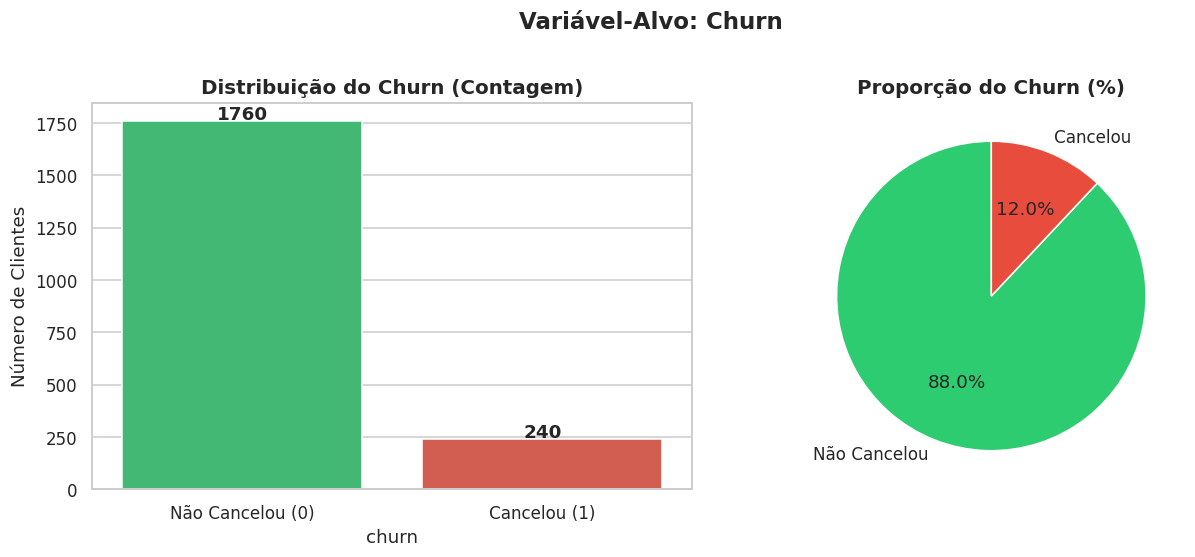


⚠️  Taxa de churn: 12.0% — dataset moderadamente balanceado


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem de Churn
vc = df_raw['churn'].value_counts()
colors = ['#2ecc71', '#e74c3c'] # Verde para Não Cancelou, Vermelho para Cancelou
sns.barplot(x=vc.index, y=vc.values, ax=axes[0], palette=colors)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Não Cancelou (0)', 'Cancelou (1)'], rotation=0)
axes[0].set_title('Distribuição do Churn (Contagem)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Proporção
perc = df_raw['churn'].value_counts(normalize=True) * 100
axes[1].pie(perc.values, labels=['Não Cancelou', 'Cancelou'],
            autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporção do Churn (%)', fontsize=13, fontweight='bold')

plt.suptitle('Variável-Alvo: Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Taxa de churn: {perc[1]:.1f}% — dataset moderadamente balanceado")

### 3.3 — Distribuições das Variáveis Numéricas

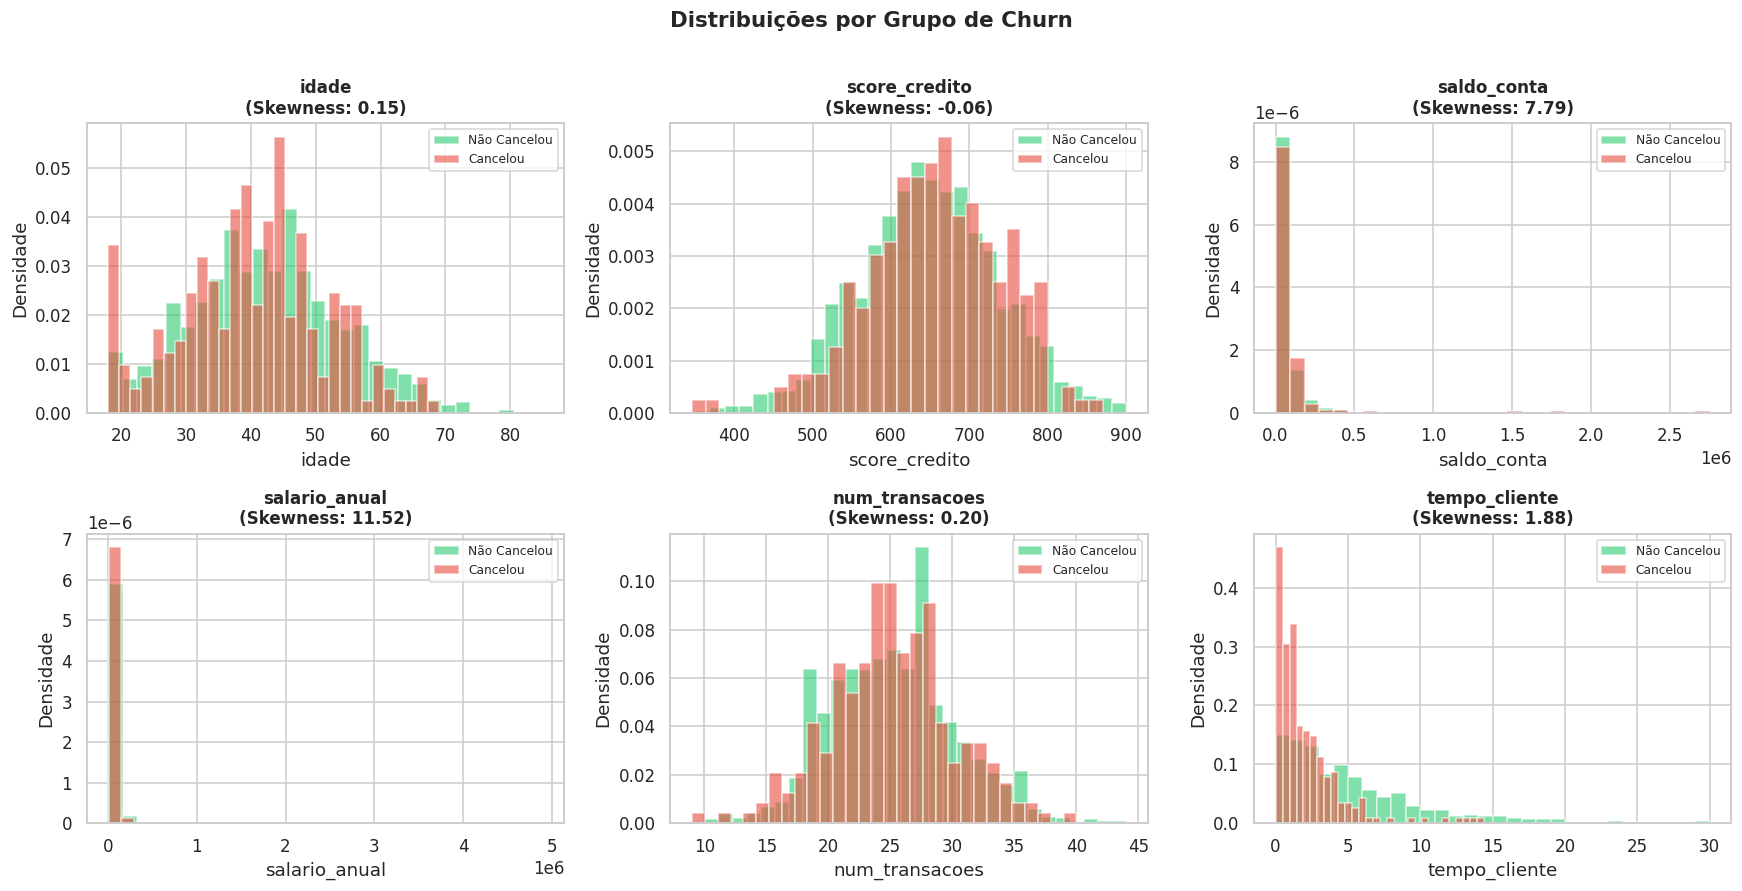


📌 Observe as distribuições assimétricas em saldo_conta e salario_anual — sinal de outliers!


In [7]:
num_cols = ['idade', 'score_credito', 'saldo_conta', 'salario_anual',
            'num_transacoes', 'tempo_cliente']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data_0 = df_raw[df_raw['churn'] == 0][col].dropna()
    data_1 = df_raw[df_raw['churn'] == 1][col].dropna()

    ax.hist(data_0, bins=30, alpha=0.6, color='#2ecc71', label='Não Cancelou', density=True)
    ax.hist(data_1, bins=30, alpha=0.6, color='#e74c3c', label='Cancelou', density=True)

    skew_val = df_raw[col].skew()
    ax.set_title(f'{col}\n(Skewness: {skew_val:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.suptitle('Distribuições por Grupo de Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📌 Observe as distribuições assimétricas em saldo_conta e salario_anual — sinal de outliers!")

### 3.4 — Análise de Correlação (Mapa de Calor)

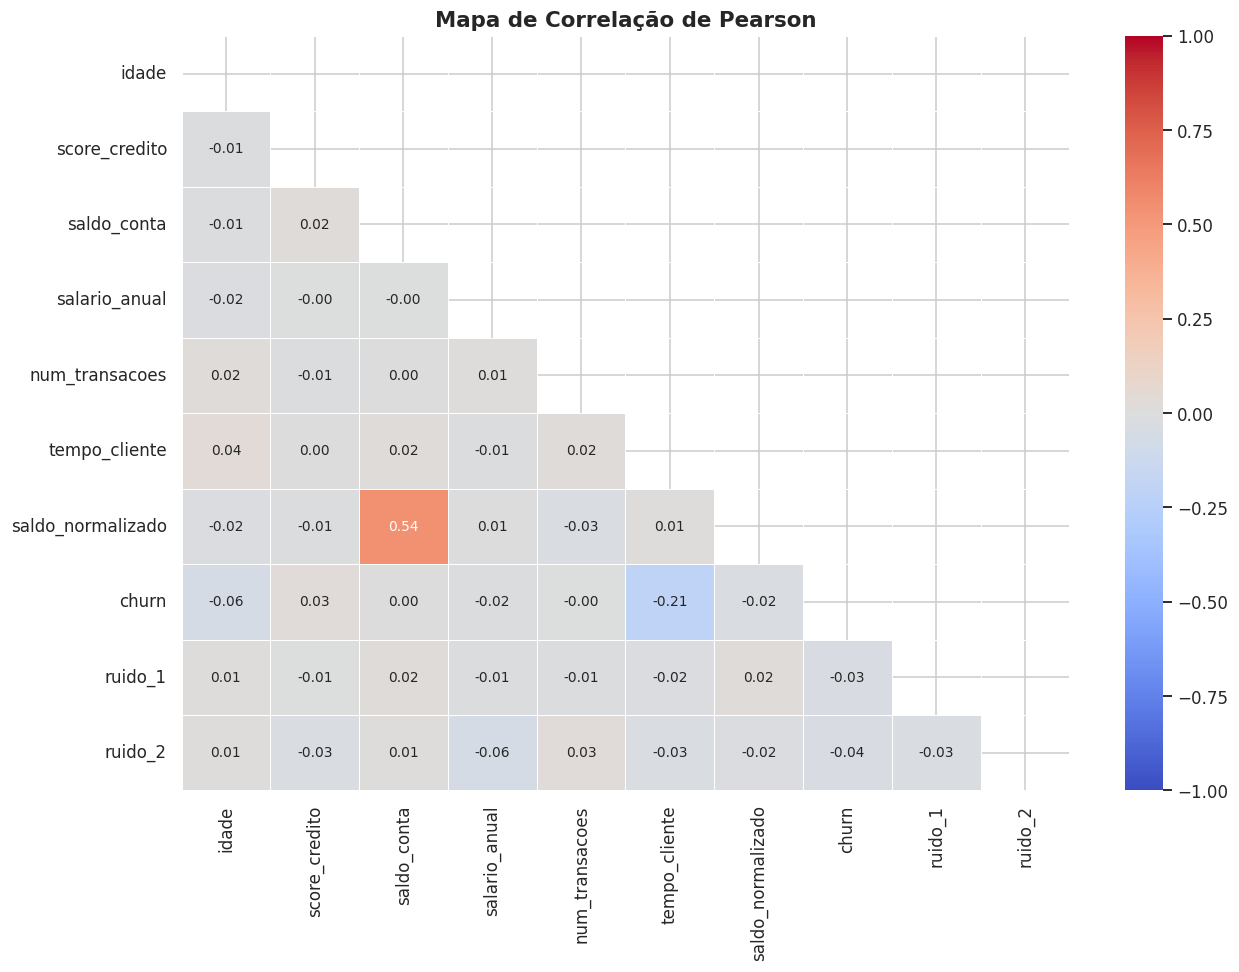


📌 Correlação das variáveis com CHURN:
tempo_cliente       -0.208779
idade               -0.060170
ruido_2             -0.035943
ruido_1             -0.033096
score_credito        0.027804
saldo_normalizado   -0.023475
salario_anual       -0.015023
num_transacoes      -0.003651
saldo_conta          0.001794

⚠️  saldo_conta e saldo_normalizado têm correlação altíssima → MULTICOLINEARIDADE!


In [8]:
# Selecionar apenas numéricas + alvo
num_df = df_raw[num_cols + ['saldo_normalizado', 'churn', 'ruido_1', 'ruido_2']].copy()

corr_matrix = num_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Mapa de Correlação de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlação com a variável-alvo
print("\n📌 Correlação das variáveis com CHURN:")
corr_churn = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
print(corr_churn.to_string())
print("\n⚠️  saldo_conta e saldo_normalizado têm correlação altíssima → MULTICOLINEARIDADE!")

### 3.5 — Visualização de Outliers com Boxplots

/tmp/ipykernel_23906/2752601697.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não Cancelou (0)', 'Cancelou (1)'])
/tmp/ipykernel_23906/2752601697.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não Cancelou (0)', 'Cancelou (1)'])
/tmp/ipykernel_23906/2752601697.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Não Cancelou (0)', 'Cancelou (1)'])


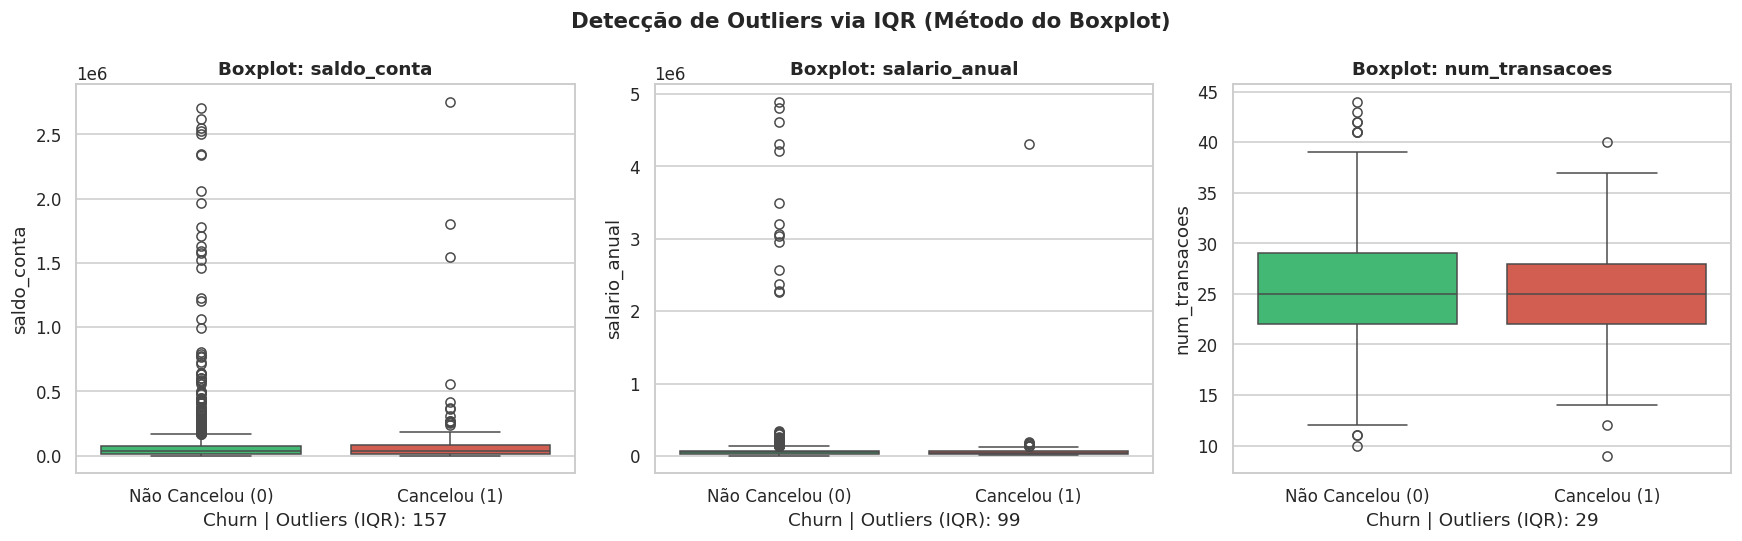


📌 Detecção de Outliers com Z-Score (|z| > 3):
  saldo_conta: 25 outliers detectados pelo Z-Score
  salario_anual: 15 outliers detectados pelo Z-Score
  num_transacoes: 9 outliers detectados pelo Z-Score


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
outlier_vars = ['saldo_conta', 'salario_anual', 'num_transacoes']

for i, col in enumerate(outlier_vars):
    ax = axes[i]
    data = df_raw[[col, 'churn']].dropna().copy()
    data['churn'] = data['churn'].astype(str)  # converter para string explícita

    sns.boxplot(
        x='churn', y=col, data=data, ax=ax,
        hue='churn',                              # fix do FutureWarning
        palette={'0': '#2ecc71', '1': '#e74c3c'}, # chaves como string
        legend=False
    )

    # Calcular IQR
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)).sum()

    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Churn | Outliers (IQR): {n_outliers}')
    ax.set_xticklabels(['Não Cancelou (0)', 'Cancelou (1)'])

plt.suptitle('Detecção de Outliers via IQR (Método do Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Detecção de Outliers com Z-Score (|z| > 3):")
for col in outlier_vars:
    z_scores = np.abs(stats.zscore(df_raw[col].dropna()))
    n_z = (z_scores > 3).sum()
    print(f"  {col}: {n_z} outliers detectados pelo Z-Score")  # <- estava fora do loop!

### 3.6 — Análise de Missing Values

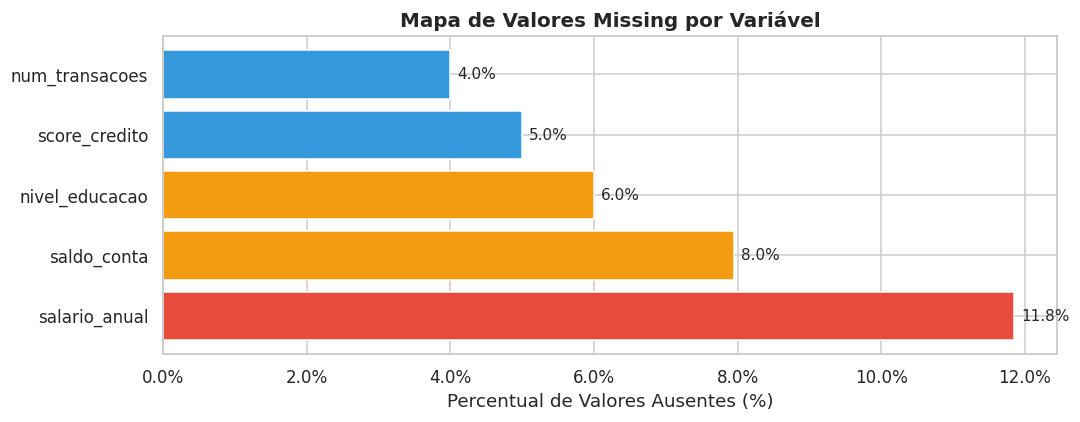

,Missing (n),Missing (%)
salario_anual,237,11.85
saldo_conta,159,7.95
nivel_educacao,120,6.00
score_credito,100,5.00
num_transacoes,80,4.00



📌 salario_anual tem 12% de missing — verificar se o padrão é MCAR, MAR ou MNAR


In [10]:
# Padrão de valores faltantes
miss_df = pd.DataFrame({
    'Missing (n)': df_raw.isnull().sum(),
    'Missing (%)': (df_raw.isnull().mean() * 100).round(2)
}).query('`Missing (n)` > 0').sort_values('Missing (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(miss_df.index, miss_df['Missing (%)'],
               color=['#e74c3c' if x > 10 else '#f39c12' if x > 5 else '#3498db'
                      for x in miss_df['Missing (%)']])
ax.set_xlabel('Percentual de Valores Ausentes (%)')
ax.set_title('Mapa de Valores Missing por Variável', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, miss_df['Missing (%)']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

display(miss_df)
print("\n📌 salario_anual tem 12% de missing — verificar se o padrão é MCAR, MAR ou MNAR")

---
## ⚙️ ETAPA 4 — Pré-processamento dos Dados

### 4.1 — Tratamento de Valores Missing

**Tipos de Missing:**
- **MCAR** (Missing Completely at Random): ausência aleatória — sem padrão
- **MAR** (Missing at Random): ausência explicada por outra variável
- **MNAR** (Missing Not at Random): ausência intencional — ex.: alto salário omitido

**Estratégias de imputação:**
| Técnica | Quando usar |
|---|---|
| Média | Dados simétricos, sem outliers |
| Mediana | Dados assimétricos ou com outliers |
| KNN Imputer | Relação estrutural entre variáveis |
| Moda | Variáveis categóricas |

In [11]:
# Fazer uma cópia de trabalho
df = df_raw.copy()

# -----------------------------------------------------------
# 4.1.1 — Imputação por MEDIANA (variáveis numéricas assimétricas)
# -----------------------------------------------------------
print("📌 Antes da imputação:")
print(df[['saldo_conta', 'score_credito', 'salario_anual', 'num_transacoes']].isnull().sum())

median_imputer = SimpleImputer(strategy='median')
df[['saldo_conta', 'salario_anual']] = median_imputer.fit_transform(
    df[['saldo_conta', 'salario_anual']])

# -----------------------------------------------------------
# 4.1.2 — Imputação por MÉDIA (score de crédito — mais simétrico)
# -----------------------------------------------------------
mean_imputer = SimpleImputer(strategy='mean')
df[['score_credito']] = mean_imputer.fit_transform(df[['score_credito']])
df['score_credito'] = df['score_credito'].round().astype(int)

# -----------------------------------------------------------
# 4.1.3 — Imputação KNN (num_transacoes — relacional)
# -----------------------------------------------------------
knn_imputer = KNNImputer(n_neighbors=5)
df[['num_transacoes']] = knn_imputer.fit_transform(
    df[['num_transacoes', 'saldo_conta', 'num_produtos']])[:, [0]]
df['num_transacoes'] = df['num_transacoes'].round().astype(int)

# -----------------------------------------------------------
# 4.1.4 — Imputação por MODA (variável categórica)
# -----------------------------------------------------------
moda = df['nivel_educacao'].mode()[0]
df['nivel_educacao'] = df['nivel_educacao'].fillna(moda)

print("\n✅ Após a imputação:")
print(df[['saldo_conta', 'score_credito', 'salario_anual', 'num_transacoes', 'nivel_educacao']].isnull().sum())

📌 Antes da imputação:
saldo_conta       159
score_credito     100
salario_anual     237
num_transacoes     80
dtype: int64

✅ Após a imputação:
saldo_conta       0
score_credito     0
salario_anual     0
num_transacoes    0
nivel_educacao    0
dtype: int64


### 4.2 — Tratamento de Outliers

**Métodos de ação:**
- **Trimming**: remover os outliers
- **Capping (Winsorização)**: limitar ao percentil 1% e 99%
- **Transformação logarítmica**: reduz a escala de variáveis assimétricas

In [ ]:
def detectar_outliers_iqr(series, nome):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    print(f"  {nome}: {n_out} outliers | limites [{lower:,.0f}, {upper:,.0f}]")
    return lower, upper

print("🔍 Detecção de Outliers (IQR):")
for col in ['saldo_conta', 'salario_anual', 'num_transacoes']:
    detectar_outliers_iqr(df[col], col)

# -----------------------------------------------------------
# Capping (Winsorização) no percentil 1% e 99%
# -----------------------------------------------------------
print("\n🔧 Aplicando Capping (Winsorização) nos percentis 1% e 99%:")
for col in ['saldo_conta', 'salario_anual']:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[f'{col}_capped'] = df[col].clip(lower=p01, upper=p99)
    print(f"  {col}: máximo ANTES = {df[col].max():,.0f} | APÓS capping = {df[f'{col}_capped'].max():,.0f}")

# -----------------------------------------------------------
# Transformação Logarítmica para reduzir assimetria
# -----------------------------------------------------------
df['log_saldo_conta']  = np.log1p(df['saldo_conta_capped'])
df['log_salario_anual'] = np.log1p(df['salario_anual_capped'])

# Visualizar efeito da transformação
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(df['saldo_conta'].dropna(), bins=40, color='#e74c3c', alpha=0.7)
axes[0,0].set_title('saldo_conta (ANTES — com outliers)', fontweight='bold')

axes[0,1].hist(df['log_saldo_conta'].dropna(), bins=40, color='#2ecc71', alpha=0.7)
axes[0,1].set_title('log_saldo_conta (APÓS transformação log)', fontweight='bold')

axes[1,0].hist(df['salario_anual'].dropna(), bins=40, color='#e74c3c', alpha=0.7)
axes[1,0].set_title('salario_anual (ANTES — com outliers)', fontweight='bold')

axes[1,1].hist(df['log_salario_anual'].dropna(), bins=40, color='#2ecc71', alpha=0.7)
axes[1,1].set_title('log_salario_anual (APÓS transformação log)', fontweight='bold')

for ax in axes.flatten():
    ax.set_ylabel('Frequência')

plt.suptitle('Efeito da Transformação Logarítmica na Assimetria', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 — Encoding de Variáveis Categóricas

| Tipo | Técnica | Exemplo |
|---|---|---|
| Nominal | One-Hot Encoding | `pais`, `tipo_conta` |
| Ordinal | Label Encoding (com ordem) | `nivel_educacao` |
| Binária | Manter como 0/1 | `genero`, `cartao_credito` |

In [ ]:
# -----------------------------------------------------------
# 4.3.1 — Label Encoding para variável ORDINAL (nivel_educacao)
# -----------------------------------------------------------
ordem_educacao = {'Ensino Médio': 0, 'Graduação': 1, 'Pós-Graduação': 2, 'Doutorado': 3}
df['nivel_educacao_enc'] = df['nivel_educacao'].map(ordem_educacao)

print("📌 Label Encoding — nivel_educacao:")
print(df[['nivel_educacao', 'nivel_educacao_enc']].drop_duplicates().sort_values('nivel_educacao_enc'))

# -----------------------------------------------------------
# 4.3.2 — Label Encoding para GÊNERO (binária)
# -----------------------------------------------------------
df['genero_enc'] = (df['genero'] == 'Feminino').astype(int)
print("\n📌 Encoding binário de gênero (Feminino=1, Masculino=0): OK")

# -----------------------------------------------------------
# 4.3.3 — One-Hot Encoding para NOMINAIS (pais, tipo_conta)
# Cuidado com a Dummy Variable Trap: drop_first=True
# -----------------------------------------------------------
df = pd.get_dummies(df, columns=['pais', 'tipo_conta'], drop_first=True, dtype=int)

ohe_cols = [c for c in df.columns if c.startswith('pais_') or c.startswith('tipo_conta_')]
print(f"\n📌 One-Hot Encoding gerou {len(ohe_cols)} novas colunas:")
print(ohe_cols)
print("\n⚠️  drop_first=True evita a Dummy Variable Trap (multicolinearidade perfeita)")

### 4.4 — Engenharia de Atributos (Feature Engineering)

In [ ]:
# -----------------------------------------------------------
# Criação de novas features com base no conhecimento de domínio
# -----------------------------------------------------------

# Razão: saldo por produto (comportamento financeiro)
df['saldo_por_produto'] = df['log_saldo_conta'] / (df['num_produtos'] + 1)

# Interação: score × tempo (clientes antigos com bom score = leais)
df['score_fidelidade'] = df['score_credito'] * df['tempo_cliente']

# Faixa etária (variável derivada discreta)
df['faixa_etaria'] = pd.cut(df['idade'],
                             bins=[17, 30, 45, 60, 100],
                             labels=['18-30', '31-45', '46-60', '61+'])
df['faixa_etaria_enc'] = df['faixa_etaria'].cat.codes

# Proporção transações/produtos
df['transacoes_por_produto'] = df['num_transacoes'] / (df['num_produtos'] + 1)

print("✅ Novas features criadas:")
new_features = ['saldo_por_produto', 'score_fidelidade', 'faixa_etaria_enc', 'transacoes_por_produto']
print(df[new_features].describe().T[['mean', 'std', 'min', 'max']])

In [ ]:
df

### 4.5 — Escalonamento de Features

**Por que escalonar?** Algoritmos baseados em distância (KNN, SVM) e gradiente descendente (redes neurais, regressão logística) são sensíveis à escala das variáveis.

| Técnica | Fórmula | Quando usar |
|---|---|---|
| Standardization (Z-Score) | `(x - μ) / σ` | Dados aproximadamente normais |
| Min-Max | `(x - min) / (max - min)` | Dados com limites conhecidos |

In [ ]:
# Definir dataset final para modelagem
feature_cols = [
    'idade', 'score_credito', 'log_saldo_conta', 'log_salario_anual',
    'num_produtos', 'num_transacoes', 'tempo_cliente',
    'cartao_credito', 'membro_ativo', 'genero_enc',
    'nivel_educacao_enc', 'faixa_etaria_enc',
    'saldo_por_produto', 'score_fidelidade', 'transacoes_por_produto',
    'ruido_1', 'ruido_2'
] + ohe_cols

X = df[feature_cols].copy()
y = df['churn'].copy()

# -----------------------------------------------------------
# Standardization (StandardScaler)
# -----------------------------------------------------------
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("📊 Comparação ANTES vs APÓS escalonamento (StandardScaler):")
comp = pd.DataFrame({
    'Média ANTES'   : X[['idade', 'score_credito', 'log_saldo_conta']].mean().round(2),
    'Std ANTES'     : X[['idade', 'score_credito', 'log_saldo_conta']].std().round(2),
    'Média APÓS'    : X_scaled[['idade', 'score_credito', 'log_saldo_conta']].mean().round(4),
    'Std APÓS'      : X_scaled[['idade', 'score_credito', 'log_saldo_conta']].std().round(4),
})
display(comp)

print("\n✅ Após StandardScaler: média ≈ 0 e desvio padrão ≈ 1 para todas as features")
print(f"\n📐 Shape do dataset final para modelagem: X = {X_scaled.shape}, y = {y.shape}")

### 4.6 — Análise de Multicolinearidade

Variáveis altamente correlacionadas entre si podem prejudicar modelos lineares e inflar a importância de features em árvores de decisão.

In [ ]:
# Remover a variável multicolinear identificada na EDA
print("📌 Correlação entre saldo_conta e saldo_normalizado (original):")
print(f"  r = {df_raw['saldo_conta'].corr(df_raw['saldo_normalizado']):.4f}")
print("  → Altíssima correlação. saldo_normalizado deve ser REMOVIDO.")

# Verificar correlações altas entre features finais
corr_features = X_scaled.corr().abs()
upper_tri = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))

high_corr = [(col, row, upper_tri.loc[row, col])
             for col in upper_tri.columns
             for row in upper_tri.index
             if upper_tri.loc[row, col] > 0.80]

print("\n📌 Pares de features com |correlação| > 0.80:")
if high_corr:
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}: r = {r:.3f}")
else:
    print("  Nenhum par com correlação > 0.80 encontrado no conjunto final.")

---
## 🌲 ETAPA 5 — Seleção de Variáveis com BORUTA

### O que é o Boruta?

> *"O Boruta é um algoritmo 'justiceiro'. O grande problema de usar apenas o `feature_importance` padrão do Random Forest é que variáveis com muito ruído ou muitas categorias podem parecer importantes puramente por acaso."*
>
> — *Aula 2 — Machine Learning PUC Minas*

### Como funciona o mecanismo das sombras:

```
1️⃣  Para cada variável original → cria uma cópia com valores EMBARALHADOS (Shadow Feature)
2️⃣  Treina um Random Forest com o dataset EXPANDIDO (Originais + Sombras)
3️⃣  Compara a importância de cada variável original com a MELHOR sombra
4️⃣  Repete N vezes (iterações) → decisão estatística via teste binomial
```

**Resultado:** cada feature é classificada como `Confirmada`, `Rejeitada` ou `Tentativa`

In [ ]:
# -----------------------------------------------------------
# Separar treino/teste antes do Boruta
# (Boruta deve ser aplicado apenas no conjunto de treino!)
# -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f"📊 Split treino/teste:")
print(f"   Treino: {X_train.shape[0]} amostras")
print(f"   Teste : {X_test.shape[0]} amostras")
print(f"   Churn no treino: {y_train.mean()*100:.1f}%  |  no teste: {y_test.mean()*100:.1f}%")

In [ ]:
# -----------------------------------------------------------
# BORUTA — Seleção de Features
# -----------------------------------------------------------
print("⏳ Executando Boruta... (pode levar 1-2 minutos)\n")

# Modelo base: Random Forest
rf_boruta = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    n_jobs=-1,
    random_state=42
)

# Boruta
boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=80,         # iterações máximas
    alpha=0.05,          # nível de significância
    verbose=1,
    random_state=42
)

boruta_selector.fit(X_train.values, y_train.values)
print("\n✅ Boruta concluído!")

In [ ]:
# -----------------------------------------------------------
# Resultados do Boruta
# -----------------------------------------------------------
support     = boruta_selector.support_          # confirmadas
support_weak = boruta_selector.support_weak_    # tentativas

results_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Ranking'   : boruta_selector.ranking_,
    'Confirmada': support,
    'Tentativa' : support_weak & ~support
})

results_df['Status'] = 'Rejeitada ❌'
results_df.loc[results_df['Confirmada'], 'Status'] = 'Confirmada ✅'
results_df.loc[results_df['Tentativa'],  'Status'] = 'Tentativa 🔶'

results_df = results_df.sort_values('Ranking')

print("\n📊 RESULTADO BORUTA — Todas as Features:")
display(results_df[['Feature', 'Ranking', 'Status']])

print("\n📌 Resumo:")
print(f"   ✅ Confirmadas : {support.sum()}")
print(f"   🔶 Tentativas  : {(support_weak & ~support).sum()}")
print(f"   ❌ Rejeitadas  : {(~support_weak).sum()}")

---
## 📝 RESUMO DO PIPELINE DE PRÉ-PROCESSAMENTO

```
Dataset Bruto
     │
     ├─ 1. EDA (ydata-profiling + análise manual)
     │       └── Identificação de: missing, outliers, assimetria, correlações
     │
     ├─ 2. Tratamento de Missing Values
     │       ├── Mediana  → saldo_conta, salario_anual (assimétricos)
     │       ├── Média    → score_credito (simétrico)
     │       ├── KNN      → num_transacoes (relacional)
     │       └── Moda     → nivel_educacao (categórico)
     │
     ├─ 3. Tratamento de Outliers
     │       ├── Capping (Winsorização) → percentis 1% / 99%
     │       └── Transformação log      → reduzir assimetria extrema
     │
     ├─ 4. Encoding Categórico
     │       ├── Label Encoding  → nivel_educacao (ordinal)
     │       ├── Binário         → genero
     │       └── One-Hot         → pais, tipo_conta (nominais, com drop_first)
     │
     ├─ 5. Feature Engineering
     │       └── saldo_por_produto, score_fidelidade, faixa_etaria, transacoes_por_produto
     │
     ├─ 6. Escalonamento
     │       └── StandardScaler → média=0, std=1
     │
     ├─ 7. Seleção de Features (BORUTA)
     │       └── Remove ruído, multicolinearidade e features irrelevantes
     │
     └─ 8. Dataset Pronto para Modelagem ✅
```

---

> 💡 **Lição Final:** *"O melhor algoritmo não sobrevive a dados mal preparados."  
> O pré-processamento rigoroso é a diferença entre um modelo que funciona e um que falha em produção.*"

---
*Disciplina: Machine Learning — PUC Minas Pós-Graduação em Ciência de Dados e Estatística*